## 1) Importing libraries

In [5]:
import numpy as np
import PIL
import pathlib
import cv2 as cv
import tensorflow as tf
import pandas as pd
import shutil
import os
import matplotlib.pyplot as plt

from functions import plots

In [6]:
random_state = 1

In [7]:
print(tf.__version__)

2.21.0


## 2) Reading data

<p>File names are stored in differents folders, each dataframe has its own <code>FILE NAME</code> column, where each file are named.</p>

### 2.1) Lung opacity

In [8]:
lung_df = pd.read_excel(
    io = "./dataset/COVID.metadata.xlsx"
)

print(lung_df.shape)
lung_df.head(2)

(3616, 4)


,FILE NAME,FORMAT,SIZE,URL
0,COVID-1,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
1,COVID-2,PNG,256*256,https://sirm.org/category/senza-categoria/covi...


### 2.2) Covid

In [9]:
covid_df = pd.read_excel(
    io = "./dataset/Lung_Opacity.metadata.xlsx"
)

print(covid_df.shape)
covid_df.head(2)

(6012, 4)


,FILE NAME,FORMAT,SIZE,URL
0,Lung_Opacity-1,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
1,Lung_Opacity-2,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...


### 2.3) Normal

In [10]:
normal_df = pd.read_excel(
    io = "./dataset/Normal.metadata.xlsx"
)

print(normal_df.shape)
normal_df.head(2)

(10192, 4)


,FILE NAME,FORMAT,SIZE,URL
0,NORMAL-1,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
1,NORMAL-2,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...


### 2.4) Viral Pneumonia

In [11]:
pneumonia_df = pd.read_excel(
    io = "./dataset/Viral Pneumonia.metadata.xlsx"
)

print(pneumonia_df.shape)
pneumonia_df.head(2)

(1345, 4)


,FILE NAME,FORMAT,SIZE,URL
0,Viral Pneumonia-1,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...
1,Viral Pneumonia-2,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...


### 2.5) Ploting images

<p>Each <code>File Name</code> corresponds to a specific archive .png contaning a mask image that needs to be separated in the original file.</p>

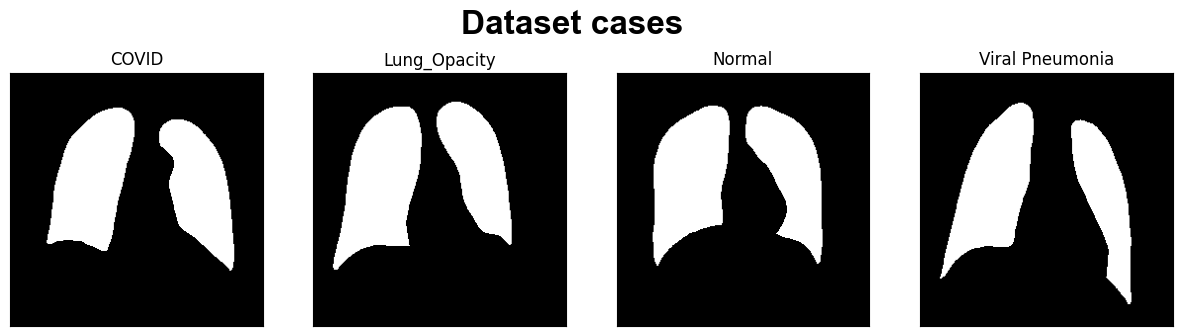

In [25]:
fig, axs = plt.subplots(
    ncols = 4,
    figsize = (15, 5)
)

axs = axs.flatten()

masks = [
    "./dataset/COVID/masks/COVID-1.png", "./dataset/Lung_Opacity/masks/Lung_Opacity-1.png",
    "./dataset/Normal/masks/Normal-1.png", "./dataset/Viral Pneumonia/masks/Viral Pneumonia-1.png"
]

for index, mask in enumerate(masks):

    axs[index].imshow(
        cv.imread(filename = mask)
    )
    axs[index].set_title(
        mask.split(r"/")[-1].split("-")[0]
    )

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(t = "Dataset cases", fontsize = 24, fontweight = "bold", fontfamily = "arial", y = .875)
plt.show()

### 2.6) Plotting data size

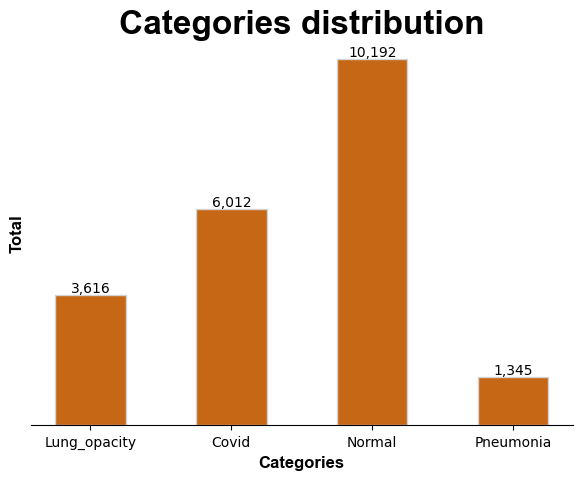

In [20]:
fig, ax = plt.subplots(
    figsize = (7, 5)
)

plots.plot_bar(
    ax = ax,
    x_values = ["Lung_opacity", "Covid", "Normal", "Pneumonia"],
    y_values = [len(lung_df), len(covid_df), len(normal_df), len(pneumonia_df)],
    colors = "#c56715",
    title = {
        "text": "Categories distribution",
        "size": 24
    },
    x_label = {
        "text": "Categories",
    },
    y_label = {
        "text": "Total"
    },
    legends = ["Lung_opacity", "Covid", "Normal", "Pneumonia"],
    tooltip_align = "edge"

)

plt.show()


## 3) Selecting

<p>Since we are trying first to create a lung model segmentation, there is no difference amoung each diasease case. In another words, there will not be any imbalanced.</p>

### 3.1) Training

<p>For training, let's select <code>frac = .75</code> imagens for each category.</p>

In [8]:
frac = .75

train_names = np.concat([
    lung_df.sample(frac = frac, random_state = random_state)["FILE NAME"].values, 
    covid_df.sample(frac = frac, random_state = random_state)["FILE NAME"].values,
    normal_df.sample(frac = frac, random_state = random_state)["FILE NAME"].values,
    pneumonia_df.sample(frac = frac, random_state = random_state)["FILE NAME"].values
])

### 3.2) Testing

<p align="justify">For testing, let's select new <code>frac = .90</code> samples for each category after excluding train set.</p>

In [9]:
frac = .90

test_names = np.concat([
    lung_df[~lung_df["FILE NAME"].isin(values = train_names)].sample(frac = frac, random_state = random_state)["FILE NAME"].values, 
    covid_df[~covid_df["FILE NAME"].isin(values = train_names)].sample(frac = frac, random_state = random_state)["FILE NAME"].values,
    normal_df[~normal_df["FILE NAME"].isin(values = train_names)].sample(frac = frac, random_state = random_state)["FILE NAME"].values,
    pneumonia_df[~pneumonia_df["FILE NAME"].isin(values = train_names)].sample(frac = frac, random_state = random_state)["FILE NAME"].values
])

### 3.3) Validation

<p>At last, for validation, let's select the leftovers.</p>

In [10]:
validation_names = np.concat([
    lung_df[~lung_df["FILE NAME"].isin(values = np.concat([train_names, test_names]))]["FILE NAME"].values, 
    covid_df[~covid_df["FILE NAME"].isin(values = np.concat([train_names, test_names]))]["FILE NAME"].values,
    normal_df[~normal_df["FILE NAME"].isin(values = np.concat([train_names, test_names]))]["FILE NAME"].values,
    pneumonia_df[~pneumonia_df["FILE NAME"].isin(values = np.concat([train_names, test_names]))]["FILE NAME"].values
])

## 4) Creating images folder

<p align = "justify">Knowing that the images are all stored in the <code>.dataset/images</code> folder, we will create a <code>segmentation</code> folder - for example - that will stored all image files saved as numpy arrays.</p>

### 4.1) Creating folders

In [11]:
if os.path.exists("./segmentation"):
    shutil.rmtree("./segmentation")
else:
    print("A pasta não existe.")

# Creating parent folder:
pathlib.Path("./segmentation").mkdir(exist_ok = True)

# Creating subfolders:
pathlib.Path("./segmentation/train").mkdir(exist_ok = True)
pathlib.Path("./segmentation/test").mkdir(exist_ok = True)
pathlib.Path("./segmentation/val").mkdir(exist_ok = True)


### 4.2) Insert images into subfolders

In [12]:
classes = ["X", "y"]
target_size = (256, 256)

for path in ["./segmentation/train", "./segmentation/test", "./segmentation/val"]:

    for class_name in classes:
        pathlib.Path(f"{path}/{class_name}").mkdir(exist_ok = True)

for path, name_list in [
    ("val", sorted(validation_names)),
    ("test", sorted(test_names)),
    ("train", sorted(train_names))
]:
    for name in name_list:
        # Colect image file and resize to the shape target_size:
        img = cv.imread(f"./dataset/images/{name}.png", cv.IMREAD_GRAYSCALE)
        img = cv.resize(src = img, dsize = target_size, interpolation = cv.INTER_CUBIC)

        # Colect mask file and resize to the shape target_size:
        mask = cv.imread(f"./dataset/masks/{name}.png", cv.IMREAD_GRAYSCALE)
        mask = cv.resize(src = mask, dsize = target_size, interpolation = cv.INTER_CUBIC)

        # Save images:
        cv.imwrite(filename = f"./segmentation/{path}/X/{name}.png", img = img)
        cv.imwrite(filename = f"./segmentation/{path}/y/{name}.png", img = mask)

### 4.3) Create data folder

In [13]:
pathlib.Path("./segmentation/numpy").mkdir(exist_ok = True)

### 4.4) Insert matrices into data folder

In [14]:
for path, name_list in [
    ("val", sorted(validation_names)),
    ("test", sorted(test_names)),
    ("train", sorted(train_names))
]:
    numpy_array = []

    for name in name_list:
        X = cv.imread(f"./segmentation/{path}/X/{name}.png", cv.IMREAD_GRAYSCALE)
        y = cv.imread(f"./segmentation/{path}/y/{name}.png", cv.IMREAD_GRAYSCALE)
        numpy_array.append(
            np.stack(arrays = [X, y])
        )
    
    numpy_array = np.array(numpy_array)

    np.save(f"./segmentation/numpy/{path}.npy", numpy_array)